# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Riadin
- **Email:** cdcc409d6y1612@student.devacademy.id
- **ID Dicoding:** CDCC409D6Y1612

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kota dan negara bagian (state) mana yang memiliki jumlah pelanggan terbanyak dalam kurun waktu tahun 2017 hingga 2018 untuk target kampanye pemasaran berikutnya?
- **Pertanyaan 2:** Berapa rata-rata waktu pengiriman pesanan dalam kurun waktu tahun 2017 hingga 2018, dan adakah keterlambatan ekstrem yang menuntut kita mengevaluasi mitra logistik?
- **Pertanyaan 3:** Kategori produk apa yang paling laris dan menyumbang pendapatan tertinggi dalam kurun waktu tahun 2017 hingga 2018 guna optimasi stok barang di gudang?

## Import Semua Packages/Library yang Digunakan

In [ ]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Keterangan import library:**
- **numpy**, bisa digunakan untuk membaca file CSV, menggabungkan tabel, membersihkan data kosong, dan mengelompokkan data.
- **pandas**, bisa digunakan untuk perhitungan matematika dasar atau manipulasi angka.
- **matplotlib & seaborn**, dua library ini akan bisa digunakan saat sudah masuk ke tahap memvisualisasikan data.

## Data Wrangling

Disini ada 3 tahap yaitu Gathering Data, Accessing Data, dan Cleaning Data. Disini saya akan menggunakan 4 dataset dari folder E-Commerce Public Dataset, yaitu `customers_dataset.csv`, `order_items_dataset.csv`, `orders_dataset_csv`, dan `products_dataset.csv`. Sebelumnya mount dulu ke drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Gathering Data

1. Memuat dan menampilkan 5 baris pertama data customers

In [ ]:
#memuat tabel customers
customers_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasetAnalisaData/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


2. Memuat dan menampilkan 5 baris pertama data order


In [ ]:
#memuat tabel orders
orders_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasetAnalisaData/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


3. Memuat dan menampilkan 5 baris pertama data order items

In [ ]:
#memuat tabel order items
order_items_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasetAnalisaData/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


4. Memuat dan menampilkan 5 baris pertama data product

In [ ]:
#memuat tabel product
products_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasetAnalisaData/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
Berdasarkan proses pemuatan 4 dataset di atas, diperoleh beberapa insight terkait struktur data yang akan dianalisis:
1. **Relasi Antar Tabel:** Data e-commerce ini terpecah menjadi beberapa tabel rasional. Untuk menjawab pertanyaan bisnis, ada tabel yang nantinya harus digabungkan (*merge*):
   - `orders_df` dan `customers_df` memiliki irisan pada kolom `customer_id`.
   - `orders_df` dan `order_items_df` memiliki irisan pada kolom `order_id`.
   - `order_items_df` dan `products_df` memiliki irisan pada kolom `product_id`.
2. **Karakteristik Data Demografi:** Tabel `customers_df`  memiliki data geografis (`customer_city` dan `customer_state`) yang sangat memadai untuk analisis persebaran wilayah pelanggan.
3. **Ketersediaan Data Logistik:** Tabel `orders_df` menyimpan rekam jejak waktu yang sangat detail (waktu pesan hingga waktu sampai) sehingga sangat memungkinkan untuk menghitung durasi *delivery time*.
4. **Ketersediaan Data Pendapatan:** Metrik untuk menghitung performa penjualan sudah tersedia secara lengkap melalui kolom `price` pada tabel `order_items_df` dan `product_category_name` pada tabel `products_df`.

### Assessing Data

1. Menilai data customers_df untuk melihat apakah ada missing values, invalid value, duplicate data, inaccurate value, inconsistent value atau outliers.

menggunakan info() untuk mengecek struktur tabel dan tipe data




In [ ]:
#menilai data customers_df
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


mengecek apakah ada missing values:

In [ ]:
#cek missing values
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


mengecek apakah ada duplicate data:

In [ ]:
#cek duplikasi data
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


menggunakan describe() untuk melihat parameter statistik:

In [ ]:
#memeriksa parameter statistik
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


2. Menilai data orders_df untuk melihat apakah ada missing values, invalid value, duplicate data, inaccurate value, inconsistent value atau outliers.

menggunakan info() untuk mengecek struktur tabel dan tipe data

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


mengecek apakah ada missing values:

In [ ]:
#cek missing values
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


mengecek apakah ada duplicate data:

In [ ]:
#cek duplikasi data
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


menggunakan describe() untuk melihat parameter statistik:

In [ ]:
#memeriksa parameter statistik
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


3. Menilai data order_items_df untuk melihat apakah ada missing values, invalid value, duplicate data, inaccurate value, inconsistent value atau outliers.

menggunakan info() untuk mengecek struktur tabel dan tipe data

In [ ]:
#menilai data order_items_df
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


mengecek apakah ada missing values:

In [ ]:
#cek missing values
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


mengecek apakah ada duplicate data:

In [ ]:
#cek duplikasi data
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


menggunakan describe() untuk melihat parameter statistik:

In [ ]:
#memeriksa parameter statistik
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


4. Menilai data products_df untuk melihat apakah ada missing values, invalid value, duplicate data, inaccurate value, inconsistent value atau outliers.

menggunakan info() untuk mengecek struktur tabel dan tipe data

In [ ]:
#menilai data products_df
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


mengecek apakah ada missing values:

In [ ]:
#cek missing values
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


mengecek apakah ada duplicate data:


In [ ]:
#cek duplikasi data
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


menggunakan describe() untuk melihat parameter statistik:

In [ ]:
#memeriksa parameter statistik
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- **Tabel customer** sudah bersih sehingga tidak perlu di cleaning
- **Tabel order** memiliki kesalahan tipe data seperti `order_purchase_timestamp` dan `order_delivered_customer_date` yang masih bertipe 'object. Ini harus diubah menjadi tipe data 'datetime' agar kalkulasi selisih waktu pengiriman dapat dilakukan pada tahap EDA.
- **Tabel order** memiliki missing value alami pada status logistik, yaitu `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`, namun akan tetap dibiarkan karena akan difilter dengan mengambil yg berstatus delivered saja.
- **Tabel order items** sudah bersih sehingga tidak perlu di cleaning (ada outlier di kolom `price` dan `freight value`, namun itu merupakan outlier alami dan wajar di dunia e-commerce)
- **Tabel product** memiliki missing values pada kolom `product_category_name`, `product_name_lenght`
`product_description_lenght`
`product_photos_qty`.

### Cleaning Data

Berdasarkan hasil insight pada Accessing Data, maka yang akan dilakukan adalah:

1. Menghapus semua duplikat untuk memastikan tidak ada data ganda di semua tabel

In [ ]:
#hapus duplikat tabel customers
customers_df.drop_duplicates(inplace=True)

#hapus duplikat tabel orders
orders_df.drop_duplicates(inplace=True)

#hapus duplikat tabel order items
order_items_df.drop_duplicates(inplace=True)

#hapus duplikat tabel products
products_df.drop_duplicates(inplace=True)

In [ ]:
#periksa kembali tabel customers
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

#periksa kembali tabel order
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

#periksa kembali tabel order items
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

#periksa kembali tabel products
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0
Jumlah duplikasi:  0
Jumlah duplikasi:  0
Jumlah duplikasi:  0


2. Pada tabel order terdapat kesalahan tipe data untuk kolom `order_purchase_timestamp` dan `order_delivered_customer_date`, kita akan menggantinya dengan tipe data 'datetime' menggunakan function to_datetime().

In [ ]:
#ganti tipe data menjadi 'datetime' dengan to_datetime()
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [ ]:
#cek lagi dengan info()
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 6.1+ MB


3. Terdapat missing value di tabel product pada beberapa kolom. Kita akan mengisinya dengan "Unknown" untuk kategori dan "0" untuk value numerik karena dalam analisis data e-commerce, menghapus (drop) baris produk hanya karena namanya kosong menghapus total uang (pendapatan) yang dihasilkan oleh produk tersebut. Mengisinya dengan Jadi adalah jalan tengah yang paling aman.

In [ ]:
# Mengisi missing value numerik dengan 0 dan kategori dengan 'unknown'
products_df['product_category_name'].fillna('unknown', inplace=True)
products_df.fillna(0, inplace=True)

/tmp/ipykernel_811/1511332233.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna('unknown', inplace=True)


In [ ]:
#cek lagi
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- **Mencegah Data Duplicates:** Meskipun pada tahap accessing data tidak terdeteksi adanya duplikat, fungsi drop_duplicates() tetap dijalankan pada keempat tabel (customers, orders, order_items, products) untuk memastikan integritas data terhindar dari error duplikasi sistem.
- **Koreksi Tipe Data Waktu (`orders_df`):** Kolom `order_purchase_timestamp` dan `order_delivered_customer_date` telah sukses dikonversi dari format teks (object) menjadi format waktu (datetime). Koreksi ini agar operasi matematis (kalkulasi durasi waktu pengiriman) dapat dilakukan di tahap analisis.
- **Imputasi Kategori Produk (`products_df`):** Sebanyak 610 produk yang tidak memiliki nama kategori (NaN) telah diisi kekosongannya  menggunakan label **"Unknown"** dan kolom dengan value numerik diisi dengan **0**. Penghapusan (drop) dihindari agar perusahaan tidak kehilangan riwayat metrik pendapatan dari transaksi produk-produk tersebut.
- **Mempertahankan *Missing Values* Natural (`orders_df`):** Nilai kosong pada kolom status logistik sengaja dipertahankan. Data ini secara akurat merepresentasikan pesanan yang memang dibatalkan (*canceled*) atau masih dalam perjalanan (*shipped*).
- **Penerimaan Outlier Alami (`order_items_df`):** Nilai ekstrem pada kolom harga barang (`price`) dan ongkos kirim (`freight_value`) tidak dihapus. Angka-angka tersebut merepresentasikan transaksi nyata berupa pembelian produk premium/mewah dan biaya logistik jarak jauh yang sangat penting untuk perhitungan total *revenue*. Saya akan menunjukkan distribusinya di tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore ...

1. **Eksplorasi data customers**

Pertama kita akan mencari tahu dari kota dan provinsi mana mayoritas pelanggan e-commerce ini berasal. Disini akan menggunakan method groupby(). Lalu agar hasilnya lebih mudah untuk dilihat, kita akan mengurutkan nilainya menggunakan method sort_values() secara descending.


In [ ]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [ ]:
#melihat persebaran jumlah customers berdasarkan kota (city)
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
agisse,1
vieiras,1
bertopolis,1


In [ ]:
#melihat persebaran jumlah customers berdasarkan negara bagian (state)
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


2. Eksplorasi data orders

Disini kita akan menghitung *delivery time * selisih hari dari saat pelanggan memencet tombol "Beli" hingga barang sampai di rumah mereka. Disini akan membuat sebuah kolom baru untuk memuat waktu pengiriman tiap order. Untuk melakukannya, kita akan menghitung selisih antar `order_delivered_customer_date` dan `order_purchase_timestamp` serta menyimpannya sebagai `delivery_time`.

Disini menggunakan method apply() untuk melakukan sebuah operasi terhadap setiap elemen dalam sebuah kolom DataFrame atau Series (bentuk satu dimensi dari DataFrame). Operasinya menghitung jumlah detik dari `delivery_time` menggunakan method total_seconds(). Nilai tersebut selanjutnya diubah ke dalam satuan hari (dibagi 86400) dan diambil bilangan bulatnya saja.

Namun sebelumnya kita filter dulu untuk ambil pesanan yang statusnya "delivered" saja.

In [ ]:
#hanya ambil pesanan yang statusnya "delivered"
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()

In [ ]:
#menghitung selisih waktu
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders_df["delivery_time"] = round(delivery_time/86400)

#cek hasil delivery_time
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,14.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,3.0


In [ ]:
#peroleh rangkuman parameter statistik dari data orders_df menggunakan method describe()
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,99441,99441,99441,99441,99281,97658,96476,99441,96476.000000
unique,99441,99441,8,NaN,90733,81018,NaN,459,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,2018-02-27 04:31:10,2018-05-09 15:48:00,NaN,2017-12-20 00:00:00,NaN
freq,1,1,96478,NaN,9,47,NaN,522,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,NaN,NaN,2018-01-14 12:09:19.035542272,NaN,12.517548
min,NaN,NaN,NaN,2016-09-04 21:15:19,NaN,NaN,2016-10-11 13:46:32,NaN,1.000000
25%,NaN,NaN,NaN,2017-09-12 14:46:19,NaN,NaN,2017-09-25 22:07:22.249999872,NaN,7.000000
50%,NaN,NaN,NaN,2018-01-18 23:04:36,NaN,NaN,2018-02-02 19:28:10.500000,NaN,10.000000
75%,NaN,NaN,NaN,2018-05-04 15:42:16,NaN,NaN,2018-05-15 22:48:52.249999872,NaN,16.000000
max,NaN,NaN,NaN,2018-10-17 17:30:18,NaN,NaN,2018-10-17 13:22:46,NaN,210.000000


3. Eksplorasi data order items dan products

Untuk mengetahui produk apa yang paling laris dan menghasilkan pendapatan tertinggi, kita harus menggabungkan (merge) tabel order items (`order_items_df`) dengan tabel produk (`products_df`). Namun sebelumnya, sebenernya ada outlier pada tabel order items pada kolom `price` dan `freight value`. Saya akan melakukan pengecekan distribusi dengan boxplot.

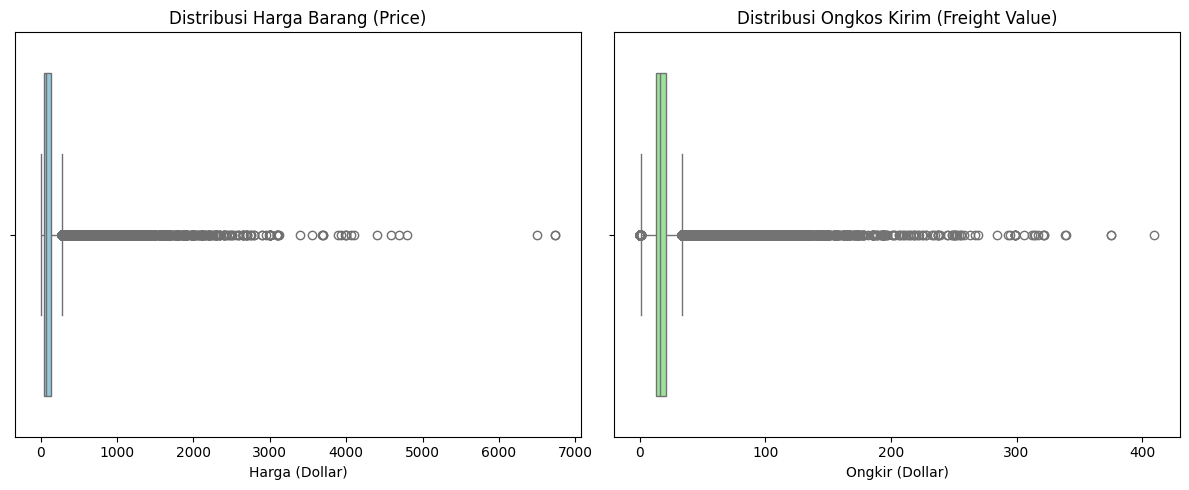

In [ ]:
# Mengatur ukuran kanvas grafik
plt.figure(figsize=(12, 5))

# Membuat Boxplot untuk kolom 'price'
plt.subplot(1, 2, 1)
sns.boxplot(x=order_items_df['price'], color='skyblue')
plt.title('Distribusi Harga Barang (Price)')
plt.xlabel('Harga (Dollar)')

# Membuat Boxplot untuk kolom 'freight_value'
plt.subplot(1, 2, 2)
sns.boxplot(x=order_items_df['freight_value'], color='lightgreen')
plt.title('Distribusi Ongkos Kirim (Freight Value)')
plt.xlabel('Ongkir (Dollar)')

# Menampilkan grafik
plt.tight_layout()
plt.show()

**Kesimpulannya:**

**SEMUA OUTLIER INI TETAP DIPERTAHANKAN** karena dalam e-commerce,
nilai harga (price) yang sangat tinggi adalah hal yang wajar dan valid karena merepresentasikan penjualan produk premium atau barang mewah.
ongkos kirim (freight_value) yang tinggi juga logis karena Brazil adalah negara yang sangat luas, sehingga pengiriman antar-negara bagian yang jauh atau pengiriman barang yang sangat berat akan memakan biaya besar.
Jika kita menghapus baris data ini, kita akan kehilangan insight penting.

In [ ]:
# Menggabungkan data order items dengan data produk
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

items_products_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [ ]:
#menghitung produk paling laris
top_products_volume = items_products_df.groupby(by="product_category_name")['order_id'].count().sort_values(ascending=False)
print(top_products_volume)

product_category_name
cama_mesa_banho                  11115
beleza_saude                      9670
esporte_lazer                     8641
moveis_decoracao                  8334
informatica_acessorios            7827
                                 ...  
cds_dvds_musicais                   14
la_cuisine                          14
pc_gamer                             9
fashion_roupa_infanto_juvenil        8
seguros_e_servicos                   2
Name: order_id, Length: 74, dtype: int64


In [ ]:
#menghitung produk dengan pendapatan tertinggi
top_products_revenue = items_products_df.groupby(by="product_category_name")['price'].sum().sort_values(ascending=False)
print(top_products_revenue)

product_category_name
beleza_saude                     1258681.34
relogios_presentes               1205005.68
cama_mesa_banho                  1036988.68
esporte_lazer                     988048.97
informatica_acessorios            911954.32
                                    ...    
flores                              1110.04
casa_conforto_2                      760.27
cds_dvds_musicais                    730.00
fashion_roupa_infanto_juvenil        569.85
seguros_e_servicos                   283.29
Name: price, Length: 74, dtype: float64


**Insight:**
- **Persebaran demografi customers**:

Berdasarkan hasil eksplorasi, terlihat jelas bahwa basis pelanggan e-commerce mayoritas berasal dari negara bagian **São Paulo (SP)** dengan total 41.746 pelanggan. Sejalan dengan data provinsi, kota **São Paulo** juga menduduki peringkat pertama sebagai kota penyumbang pelanggan terbanyak (15.540 pelanggan), disusul oleh Rio de Janeiro (6.882). Informasi ini sangat krusial untuk menargetkan kampanye pemasaran (*Ads*) geografis dan promosi ongkos kirim pada masa mendatang.
- **Waktu Pengiriman (Delivery Time)**:

Dari rangkuman parameter statistik, dapat disimpulkan bahwa rata-rata (*mean*) waktu yang dibutuhkan pesanan berstatus *delivered* untuk sampai ke tangan pelanggan adalah sekitar **12,5 hari** (sekitar 12-13 hari).

Meskipun secara umum waktu pengiriman cukup baik (ada yang tercepat hanya 1 hari), terdapat **keterlambatan ekstrem (anomali)** di mana pesanan paling lama baru sampai setelah **210 hari**. Hal ini menjadi indikator penting bagi perusahaan untuk segera mengevaluasi kinerja mitra logistik/kurir pada rute-rute pengiriman yang bermasalah tersebut.
- **Produk paling laris dan pendapatan tertinggi:**

Kategori produk yang paling sering dibeli oleh pelanggan adalah cama_mesa_banho (kebutuhan kamar tidur & kamar mandi) dengan total 11.115 pesanan, disusul oleh beleza_saude (kecantikan & kesehatan). Namun jika dilihat dari total uang yang dihasilkan, kategori beleza_saude justru menempati peringkat pertama sebagai penyumbang omzet terbesar bagi perusahaan (mencapai $1.258.681), sedangkan cama_mesa_banho turun ke peringkat ketiga.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kota dan negara bagian (state) mana yang memiliki jumlah pelanggan terbanyak dalam kurun waktu tahun 2017 hingga 2018 untuk target kampanye pemasaran berikutnya?

Untuk mempresentasikan kota dan negara bagian dengan customer terbanyak, saya akan memvisualisasikannya dengan diagram batang (bar chart).

/tmp/ipykernel_811/231149910.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_cities.values, y=top_5_cities.index, palette="viridis", ax=ax[0])
/tmp/ipykernel_811/231149910.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_states.values, y=top_5_states.index, palette="magma", ax=ax[1])


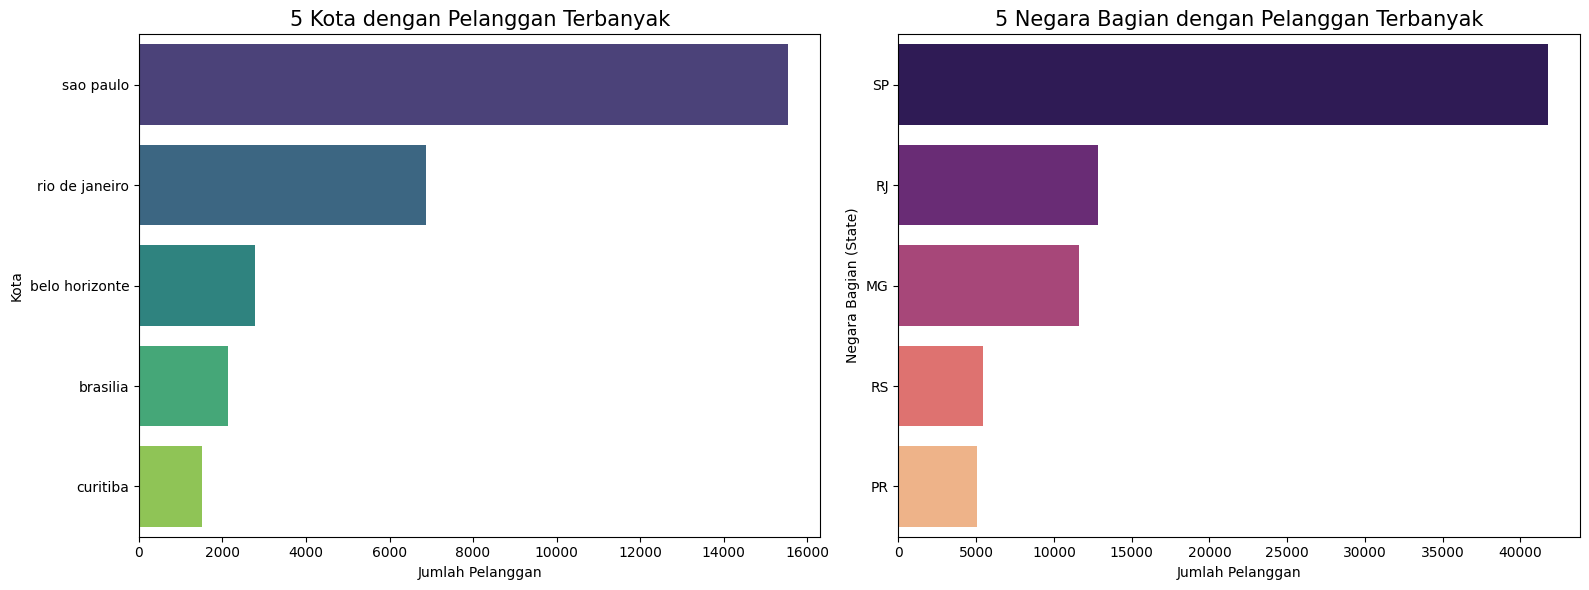

In [ ]:
# Menyiapkan data untuk visualisasi
top_5_cities = customers_df['customer_city'].value_counts().head(5)
top_5_states = customers_df['customer_state'].value_counts().head(5)

# Membuat kanvas (figure) dengan 2 subplot bersebelahan
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: 5 Kota Teratas
sns.barplot(x=top_5_cities.values, y=top_5_cities.index, palette="viridis", ax=ax[0])
ax[0].set_title("5 Kota dengan Pelanggan Terbanyak", fontsize=15)
ax[0].set_xlabel("Jumlah Pelanggan")
ax[0].set_ylabel("Kota")

# Grafik 2: 5 Negara Bagian (State) Teratas
sns.barplot(x=top_5_states.values, y=top_5_states.index, palette="magma", ax=ax[1])
ax[1].set_title("5 Negara Bagian dengan Pelanggan Terbanyak", fontsize=15)
ax[1].set_xlabel("Jumlah Pelanggan")
ax[1].set_ylabel("Negara Bagian (State)")

plt.tight_layout()
plt.show()

**Explanatory Analysis (Pertanyaan 1):**

Berdasarkan visualisasi grafik batang di atas, sangat jelas terlihat adanya ketimpangan demografi (dominasi) yang signifikan. Kota **São Paulo** dan negara bagian **SP (São Paulo)** merupakan basis pelanggan terbesar perusahaan dengan jarak yang sangat jauh memimpin dibandingkan wilayah lainnya (seperti Rio de Janeiro atau Minas Gerais).
* **Rekomendasi Bisnis:** Tim marketing sangat disarankan untuk mengalokasikan anggaran iklan (*Ads*) yang lebih besar ke wilayah São Paulo. Selain itu, penambahan pusat distribusi/gudang logistik di wilayah SP dan RJ akan sangat efektif untuk melayani mayoritas pelanggan ini.

### Pertanyaan 2:  Berapa rata-rata waktu pengiriman pesanan dalam kurun waktu tahun 2017 hingga 2018, dan adakah keterlambatan ekstrem yang menuntut kita mengevaluasi mitra logistik?

Untuk mempresentasikan waktu pengiriman, saya akan memvisualisasikan dengan histogram.

***Note:**
Grafik di bawah difokuskan pada pesanan di bawah 60 hari untuk melihat detail distribusi. Terdapat outlier (data pencilan) dengan keterlambatan hingga 210 hari yang tidak ditampilkan dalam grafik agar visual tetap terbaca jelas (namun saya akan tetap memperlihatkan secara terpisah).

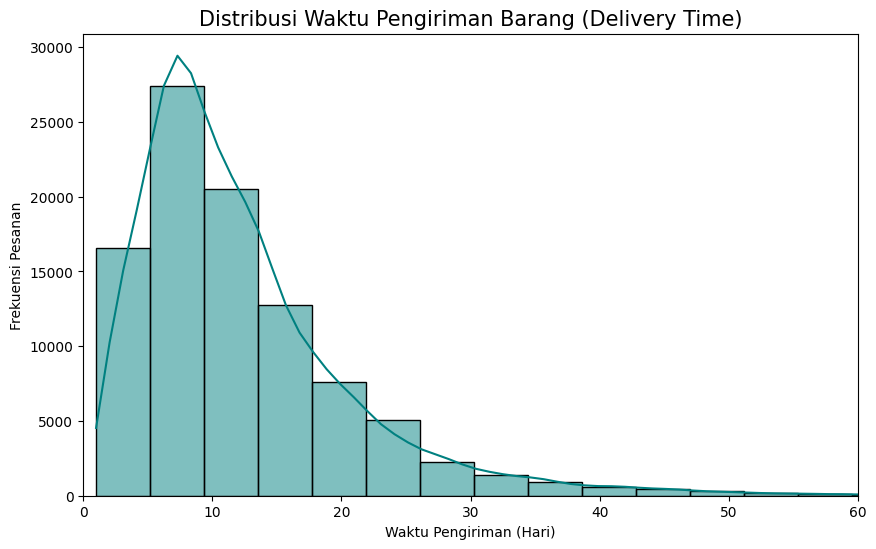

In [ ]:
plt.figure(figsize=(10, 6))

# Membuat histogram distribusi waktu pengiriman
sns.histplot(x=orders_df['delivery_time'], bins=50, kde=True, color="teal")

plt.title("Distribusi Waktu Pengiriman Barang (Delivery Time)", fontsize=15)
plt.xlabel("Waktu Pengiriman (Hari)")
plt.ylabel("Frekuensi Pesanan")

# Membatasi sumbu X sampai 60 hari saja agar grafik lebih fokus (karena ada outlier sampai 210 hari)
plt.xlim(0, 60)
plt.show()

**Explanatory Analysis (Pertanyaan 2):**


Visualisasi histogram di atas menunjukkan distribusi yang Right-Skewed (menjulur ke kanan). Artinya, mayoritas pesanan berhasil dikirimkan dalam kurun waktu yang cepat, yaitu pada puncaknya sekitar **7 hingga 15 hari**. Garis kurva (KDE) juga menunjukkan penurunan drastis setelah melewati angka 20 hari.
* **Rekomendasi Bisnis:** Secara rata-rata, mitra logistik sudah bekerja dengan cukup baik di bawah 2 minggu. Namun, ekor grafik yang memanjang ke kanan (bahkan hingga 210 hari pada data mentah) mengonfirmasi adanya kasus keterlambatan ekstrem. Perusahaan harus menerapkan sistem *tracking* otomatis yang akan memberikan peringatan dini (*alert*) jika barang belum sampai setelah melewati batas 15 hari, agar Customer Service bisa proaktif menghubungi pihak logistik sebelum pelanggan komplain.

Histogram versi utuh

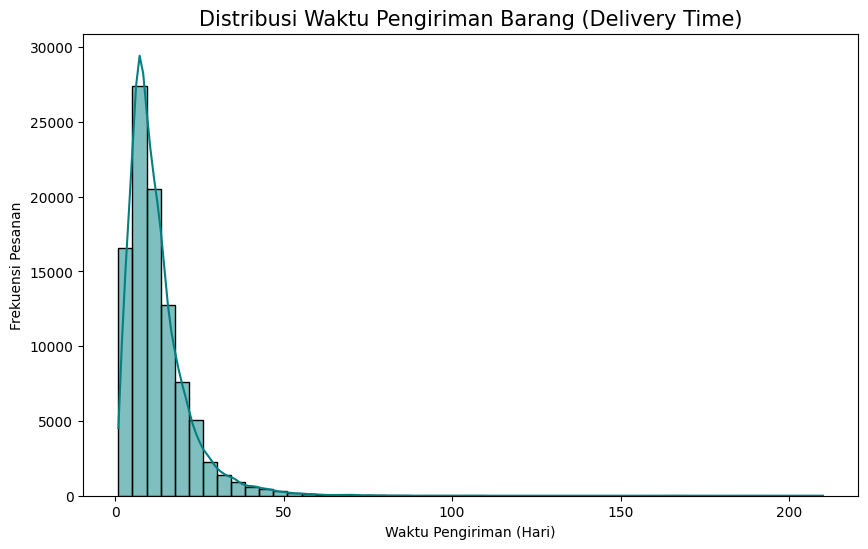

In [ ]:
plt.figure(figsize=(10, 6))

# Membuat histogram distribusi waktu pengiriman (Versi Utuh)
sns.histplot(x=orders_df['delivery_time'], bins=50, kde=True, color="teal")

plt.title("Distribusi Waktu Pengiriman Barang (Delivery Time)", fontsize=15)
plt.xlabel("Waktu Pengiriman (Hari)")
plt.ylabel("Frekuensi Pesanan")

plt.show()

### Pertanyaan 3:  Kategori produk apa yang paling laris dan menyumbang pendapatan tertinggi dalam kurun waktu tahun 2017 hingga 2018 guna optimasi stok barang di gudang?

Untuk mempresentasikan produk paling laris dan pendapatan tertinggi, saya akan memvisualisasi dengan diagram batang (bar chart)

/tmp/ipykernel_811/3398298357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_volume.values, y=top_5_volume.index, palette="Blues_r", ax=ax[0])
/tmp/ipykernel_811/3398298357.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_revenue.values, y=top_5_revenue.index, palette="Greens_r", ax=ax[1])


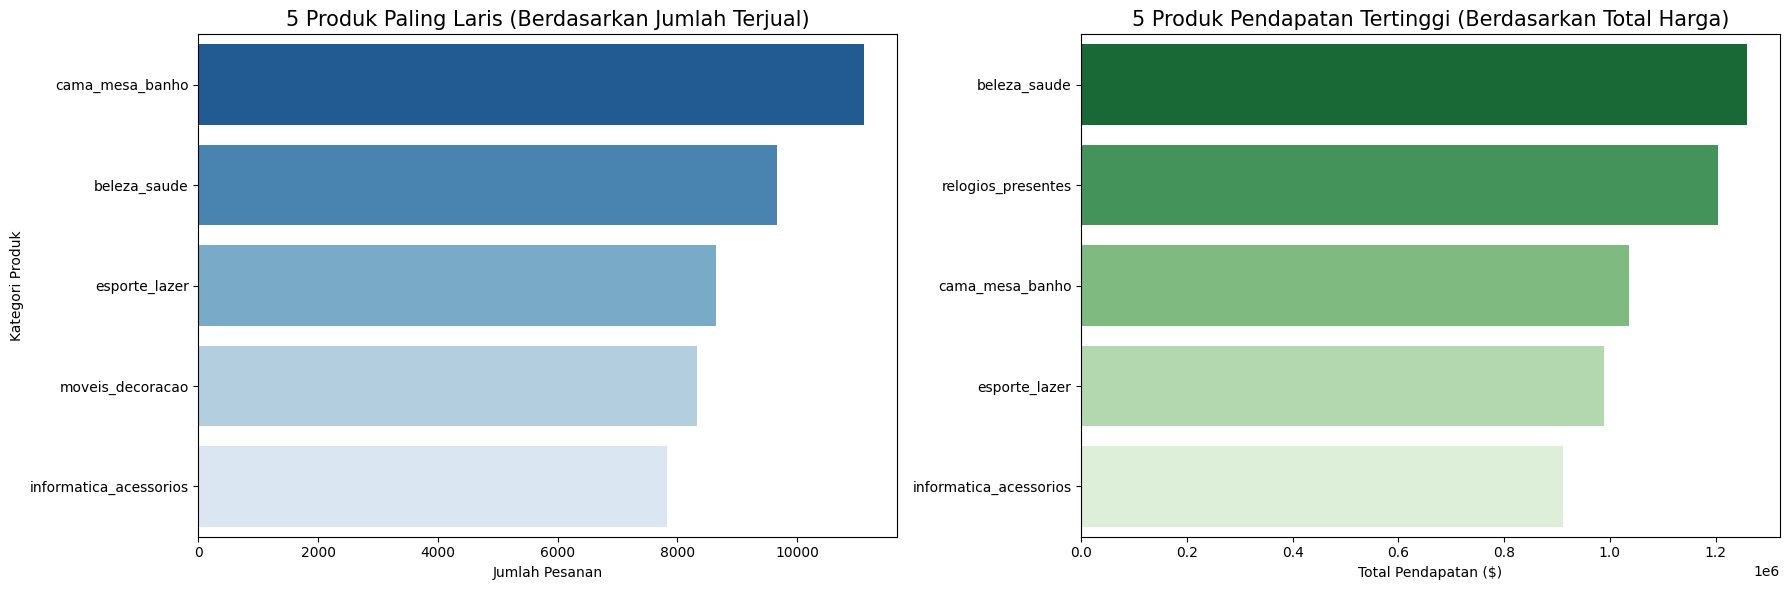

In [ ]:
# Menyiapkan data (mengambil 5 teratas)
top_5_volume = top_products_volume.head(5)
top_5_revenue = top_products_revenue.head(5)

# Membuat kanvas (figure) dengan 2 subplot bersebelahan
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Berdasarkan Volume (Paling Laris)
sns.barplot(x=top_5_volume.values, y=top_5_volume.index, palette="Blues_r", ax=ax[0])
ax[0].set_title("5 Produk Paling Laris (Berdasarkan Jumlah Terjual)", fontsize=15)
ax[0].set_xlabel("Jumlah Pesanan")
ax[0].set_ylabel("Kategori Produk")

# Grafik 2: Berdasarkan Revenue (Pendapatan Tertinggi)
sns.barplot(x=top_5_revenue.values, y=top_5_revenue.index, palette="Greens_r", ax=ax[1])
ax[1].set_title("5 Produk Pendapatan Tertinggi (Berdasarkan Total Harga)", fontsize=15)
ax[1].set_xlabel("Total Pendapatan ($)")
ax[1].set_ylabel("") # Sengaja kosong biar rapi

plt.tight_layout()
plt.show()

**Explanatory Analysis (Pertanyaan 3):**


Dari dua visualisasi di atas, kita dapat melihat pola bisnis yang berbanding terbalik:
1. Grafik sebelah kiri menunjukkan bahwa produk **cama_mesa_banho** adalah penyumbang volume penjualan terbesar (barang yang paling sering terjual).
2. Namun, pada grafik sebelah kanan, produk **beleza_saude** (kecantikan & kesehatan) dan **relogios_presentes** (jam tangan) adalah penyumbang omzet (uang) terbesar, meskipun jumlah transaksinya tidak sebanyak produk tempat tidur/kamar mandi.
* **Rekomendasi Bisnis:** Strategi manajemen gudang (inventory) harus memastikan stok produk *cama_mesa_banho* selalu tersedia melimpah karena perputarannya (demand) sangat tinggi. Sementara itu, tim marketing dan sales sebaiknya lebih sering mempromosikan produk *beleza_saude* dan *relogios_presentes* karena margin dan total keuntungan uang yang dihasilkan jauh lebih menguntungkan perusahaan.

**Insight:**

**1. Optimalisasi Pasar Berbasis Wilayah (Geografis)**
* **Temuan Utama**: Konsentrasi pelanggan sangat terpusat di wilayah **São Paulo (SP)**, baik di tingkat negara bagian (41.746 pelanggan) maupun kota (15.540 pelanggan). Wilayah ini memiliki penetrasi pasar yang jauh lebih tinggi dibandingkan wilayah lainnya di Brazil.
* **Aksi Strategis**:
    * Fokuskan alokasi anggaran kampanye pemasaran digital (*Ads*) pada wilayah São Paulo untuk memaksimalkan ROI (*Return on Investment*).
    * Pertimbangkan untuk memberikan promo khusus "Gratis Ongkir" atau "Pengiriman Ekspres" untuk wilayah di luar SP (seperti Rio de Janeiro atau Minas Gerais) guna meningkatkan daya tarik dan memperluas pangsa pasar di wilayah tersebut.

**2. Penguatan Manajemen Logistik & Layanan Pelanggan**
* **Temuan Utama**: Rata-rata waktu pengiriman barang adalah **12,5 hari**. Mayoritas pesanan sampai dalam waktu 10-15 hari. Namun, adanya keterlambatan ekstrem hingga **210 hari** menunjukkan adanya masalah serius pada jalur pengiriman tertentu atau kinerja kurir tertentu.
* **Aksi Strategis**:
    * **Evaluasi Mitra Kurir**: Lakukan audit berkala terhadap mitra logistik yang menangani rute-rute dengan keterlambatan di atas 30 hari.
    * **Sistem Peringatan Dini**: Terapkan sistem pelacakan otomatis yang memberikan notifikasi (*alert*) kepada tim *Customer Service* jika status pesanan belum berubah menjadi 'delivered' dalam waktu 20 hari, agar perusahaan dapat bersikap proaktif sebelum pelanggan memberikan penilaian buruk.

**3. Diferensiasi Strategi Produk (Volume vs Value)**
* **Temuan Utama**: Terdapat perbedaan profil pelanggan antara pembeli volume besar dan pembeli barang premium.
    * Kategori **`cama_mesa_banho`** adalah produk yang paling sering terjual (kebutuhan harian).
    * Kategori **`beleza_saude`** adalah penyumbang pendapatan tertinggi (**$1.258.681,34**), diikuti oleh **`relogios_presentes`**.
* **Aksi Strategis**:
    * **Inventory Management**: Stok untuk kategori *cama_mesa_banho* harus dijaga ketat agar tidak terjadi *out-of-stock* karena permintaannya sangat stabil dan tinggi.
    * **Premium Marketing**: Karena kategori kecantikan (*beleza_saude*) dan jam tangan (*relogios_presentes*) memberikan margin keuntungan yang lebih besar per transaksi, tim marketing sebaiknya membuat konten promosi yang menonjolkan aspek kualitas dan eksklusivitas untuk kategori-kategori ini guna terus mendorong angka pendapatan.

## Analisis Lanjutan (Opsional)

**RFM Analysis**

Karena ini data e-commerce, maka analisis yang dilakukan adalah dengan RFM Analysis, dimana akan menghitung tiga metrik ini:

- Recency: Kapan terakhir kali pelanggan melakukan transaksi (dalam hari).

- Frequency: Berapa kali pelanggan melakukan transaksi.

- Monetary: Berapa total uang yang dihabiskan pelanggan.

In [ ]:
# 1. Gunakan 'delivered_orders' (yang sudah difilter status delivered di tahap EDA sebelumnya)
# Gabungkan dengan data item (untuk dapat harga) dan customer (untuk dapat ID unik)
all_df = pd.merge(
    left=items_products_df,
    right=delivered_orders, # Menggunakan yang sudah difilter
    how="inner",
    on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=customers_df,
    how="inner",
    on="customer_id"
)

# 2. Lanjutkan ke hitungan RFM (Gunakan customer_unique_id agar lebih akurat)
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max", # ambil tanggal order terakhir
    "order_id": "nunique",             # menghitung jumlah order unik
    "price": "sum"                     # menghitung jumlah revenue
})

rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# 3. Hitung selisih hari (Recency)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = all_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,customer_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,114
2,0000f46a3911fa3c0805444483337064,1,69.00,537
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,321
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,288


Untuk melengkapi analisis ini, kita buat grafik batang untuk masing-masing parameter (Recency, Frequency, Monetary) berdasarkan ID pelanggan terbaik.

/tmp/ipykernel_811/1927611123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="short_id", data=top_recency, palette=colors, ax=ax[0])
/tmp/ipykernel_811/1927611123.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="short_id", data=top_frequency, palette=colors, ax=ax[1])
/tmp/ipykernel_811/1927611123.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="short_id", data=top_monetary, palette=colors, ax=ax[2])


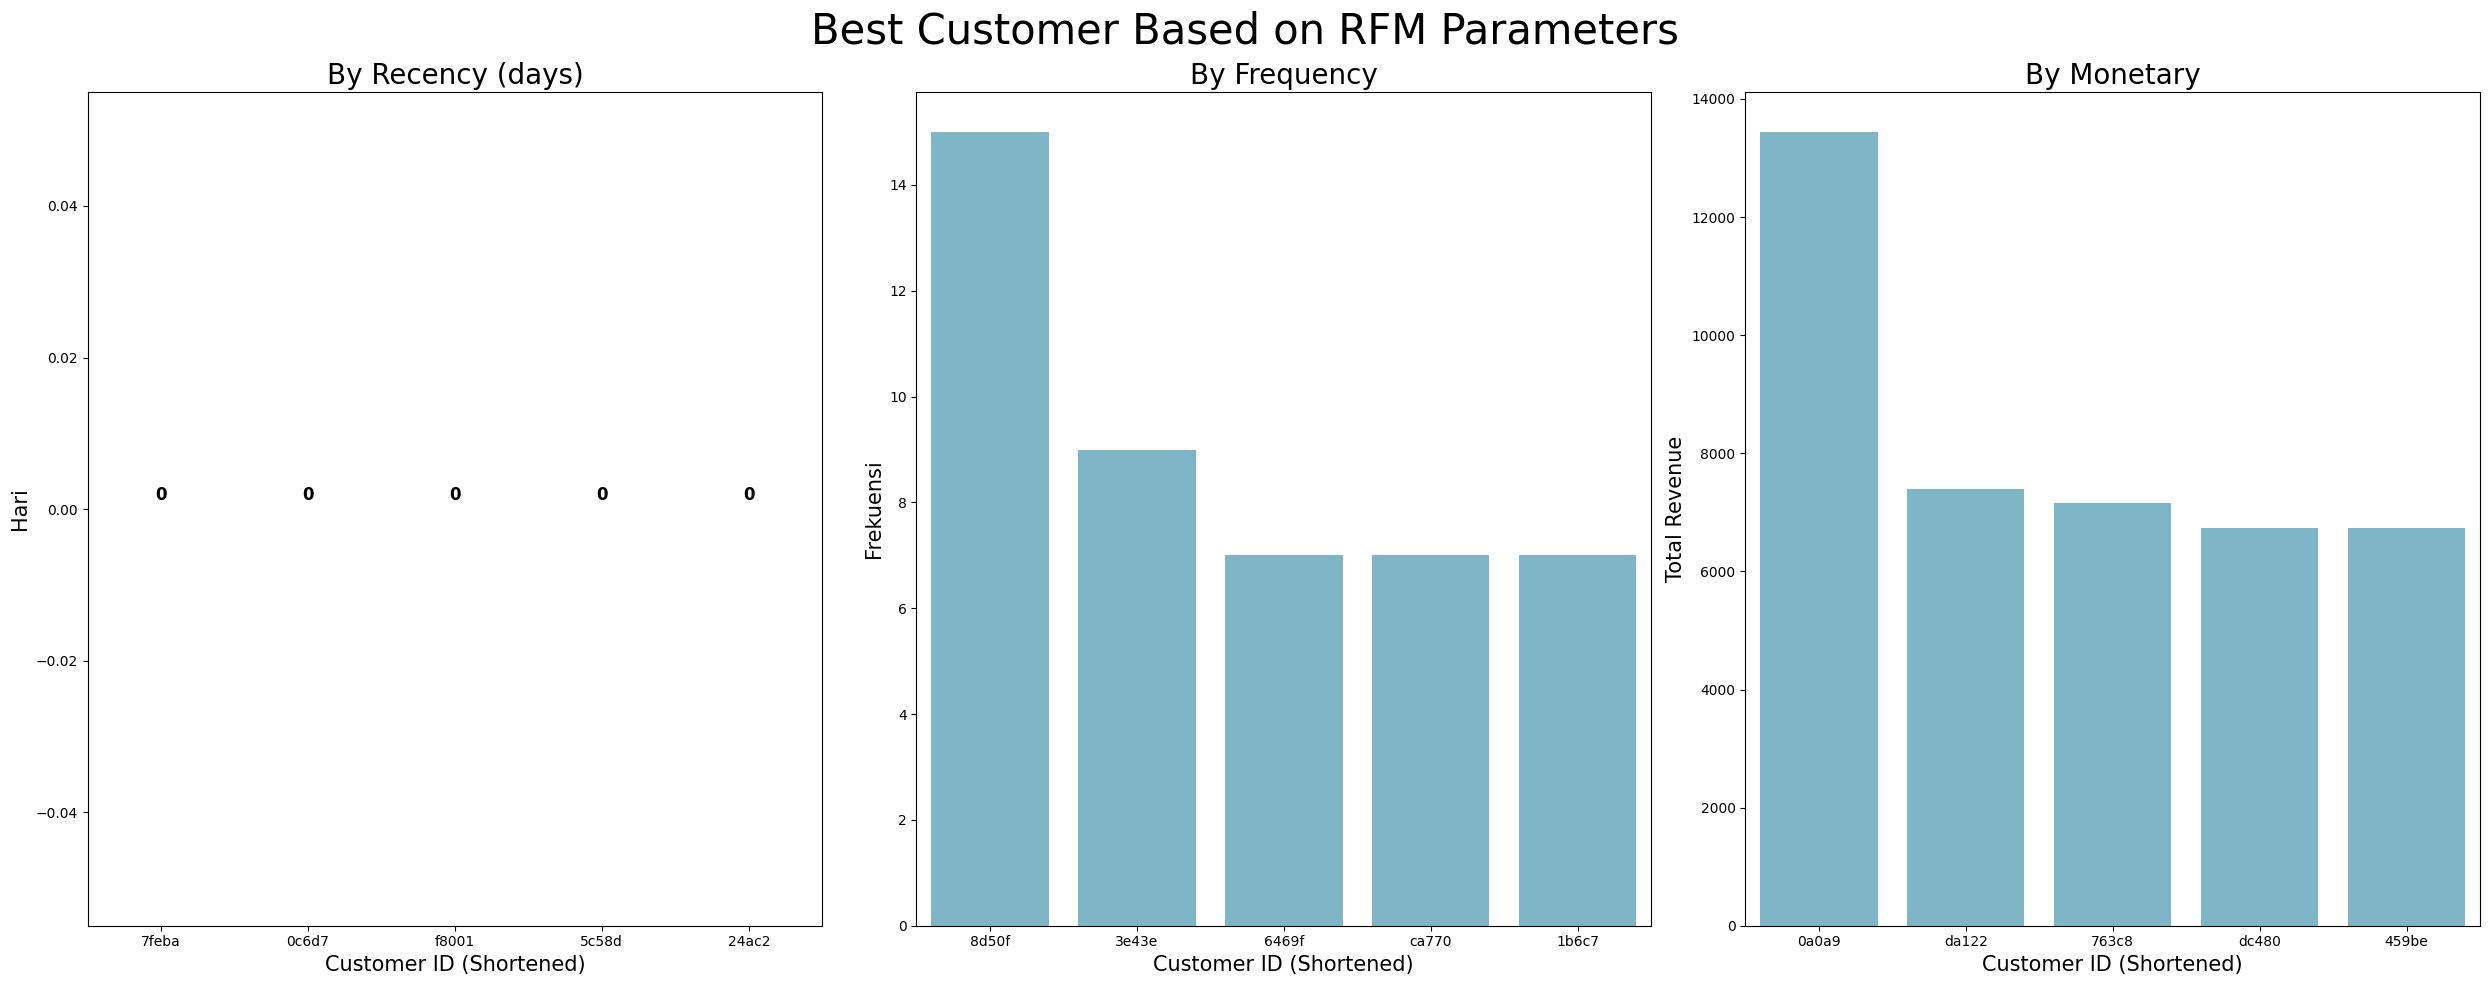

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(25, 10))
colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# 1. By recency
# Ambil 5 terbaik, potong ID jadi 5 huruf awal demi estetika
top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5).copy()
top_recency['short_id'] = top_recency['customer_id'].str[:5]

sns.barplot(y="recency", x="short_id", data=top_recency, palette=colors, ax=ax[0])
ax[0].set_ylabel("Hari", fontsize=15)
ax[0].set_xlabel("Customer ID (Shortened)", fontsize=15)
ax[0].set_title("By Recency (days)", loc="center", fontsize=20)

# Menambah label angka di atas batang (agar angka 0 terlihat)
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points',
                   fontsize=12, color='black', weight='bold')

# by frequency
top_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
top_frequency['short_id'] = top_frequency['customer_id'].str[:5]

sns.barplot(y="frequency", x="short_id", data=top_frequency, palette=colors, ax=ax[1])
ax[1].set_ylabel("Frekuensi", fontsize=15)
ax[1].set_xlabel("Customer ID (Shortened)", fontsize=15)
ax[1].set_title("By Frequency", loc="center", fontsize=20)

# by monetary
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()
top_monetary['short_id'] = top_monetary['customer_id'].str[:5]

sns.barplot(y="monetary", x="short_id", data=top_monetary, palette=colors, ax=ax[2])
ax[2].set_ylabel("Total Revenue", fontsize=15)
ax[2].set_xlabel("Customer ID (Shortened)", fontsize=15)
ax[2].set_title("By Monetary", loc="center", fontsize=20)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=30)
plt.tight_layout()
plt.show()

### **Explanatory Analysis (Analisis Lanjutan: RFM)**

Berdasarkan visualisasi RFM di atas, kita dapat membedah perilaku 5 pelanggan terbaik dari tiga sudut pandang yang berbeda:

1. **Recency (Kebaruan Transaksi)**:
   * **Analisis**: Pada grafik pertama, kita melihat beberapa pelanggan memiliki skor 0 (nol) hari. Hal ini ditandai dengan angka 0 di atas grafik meskipun batangnya tidak terlihat.
   * **Makna**: Ini adalah pelanggan yang baru saja melakukan transaksi pada hari terakhir data dicatat. Mereka adalah kelompok yang paling "hangat" dan paling mungkin memberikan respon positif jika diberikan penawaran produk pelengkap (*cross-selling*) saat ini juga.

2. **Frequency (Loyalitas/Frekuensi)**:
   * **Analisis**: Di tengah dominasi "one-time buyers" pada platform e-commerce ini, kita berhasil mengidentifikasi segmen pelanggan yang melakukan transaksi lebih dari satu kali (terlihat pada angka frekuensi di sumbu Y).
   * **Makna**: Meskipun jumlahnya sedikit, mereka adalah pelanggan loyal. Perusahaan tidak perlu mengeluarkan biaya akuisisi (*Customer Acquisition Cost*) lagi untuk mereka, sehingga mempertahankan kelompok ini jauh lebih murah dan menguntungkan daripada mencari pelanggan baru.

3. **Monetary (Kontribusi Pendapatan)**:
   * **Analisis**: Grafik ketiga menampilkan para pelanggan dengan nilai transaksi terbesar. Satu orang pelanggan di kategori ini bisa memberikan kontribusi pendapatan yang setara dengan puluhan pelanggan biasa.
   * **Makna**: Kehilangan satu pelanggan di daftar ini akan berdampak signifikan pada total *revenue* perusahaan. Mereka wajib mendapatkan perlakuan istimewa (misalnya Layanan Prioritas).

**Rangkuman Strategis**:
ID Pelanggan yang muncul di daftar *Monetary* namun memiliki angka *Recency* yang tinggi (sudah lama tidak belanja) adalah target utama untuk kampanye **Win-back Strategy**. Kita harus mencoba memenangkan mereka kembali sebelum mereka benar-benar beralih ke kompetitor.

## Conclusion

### **Conclusion**

**Pertanyaan 1: Kota dan negara bagian mana yang memiliki jumlah pelanggan terbanyak dalam kurun waktu 2017 hingga 2018?**
- Kesimpulannya, mayoritas pelanggan terpusat di wilayah  negara bagian **São Paulo (SP)** dengan total lebih dari 41.000 pelanggan. Di tingkat kota, **São Paulo** juga menduduki peringkat pertama. Hal ini menunjukkan bahwa strategi pemasaran dan ekspansi operasional selanjutnya harus tetap memprioritaskan wilayah ini sebagai basis ekonomi utama, sambil mencoba melakukan penetrasi bertahap ke wilayah potensial lainnya seperti Rio de Janeiro.

**Pertanyaan 2: Berapa rata-rata waktu pengiriman pesanan dalam kurun waktu 2017 hingga 2018 dan apakah ada keterlambatan ekstrem?**
- Rata-rata waktu pengiriman pesanan adalah sekitar **12,5 hari**, dengan mayoritas pengiriman selesai dalam kurun waktu 10-15 hari. Namun, ditemukan anomali berupa keterlambatan ekstrem yang mencapai **210 hari**. Kesimpulannya, meskipun performa rata-rata sudah cukup baik, perusahaan perlu mengevaluasi kembali kontrak kerja sama dengan mitra logistik pada rute-rute tertentu yang sering mengalami *delay* panjang guna menjaga tingkat kepuasan pelanggan.

**Pertanyaan 3: Kategori produk apa yang paling laris dan menyumbang pendapatan tertinggi dalam kurun waktu 2017 hingga 2018?**
- Terdapat perbedaan antara volume penjualan dan nilai pendapatan. Produk paling laris secara kuantitas adalah kategori **`cama_mesa_banho`** (perlengkapan tidur & mandi). Namun, kontributor pendapatan (*revenue*) tertinggi adalah kategori **`beleza_saude`** (kecantikan & kesehatan) dengan total mencapai **$1.258.681,34**. Strategi optimasi stok harus memastikan ketersediaan barang *fast-moving* seperti perlengkapan rumah tangga, sementara strategi promosi harus difokuskan pada produk kategori kecantikan untuk memaksimalkan profitabilitas perusahaan.

##Simpan semua data

In [ ]:
# Tentukan kolom-kolom yang hanya dipakai di dashboard
#(saya awalnya simpan semua tapi ukuran terlalu besar untuk diupload ke GitHub untuk keperluan deploy)
kolom_penting = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "price",
    "customer_city",
    "customer_state",
    "product_category_name"
]

# Simpan hanya dengan kolom penting tersebut
all_df[kolom_penting].to_csv("all_data.csv", index=False)